# Step 4 — Train Ranking Model
This notebook trains a machine learning model to score and rank candidates.

**Full pipeline in this notebook:**
1. Load raw CSV
2. Explore data (understand what we have)
3. Clean data (handle missing values, duplicates, outliers)
4. Feature engineering (scale, encode)
5. Train model (Random Forest)
6. Evaluate model
7. Save model + scaler + feature columns


## 1. Imports

In [1]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import joblib
import warnings
warnings.filterwarnings("ignore")

sys.path.append(os.path.dirname(os.getcwd()))
from config import CANDIDATES_CSV, RANKING_MODEL_PATH, FEATURE_COLS_PATH, SCALER_PATH, MODELS_DIR

os.makedirs(MODELS_DIR, exist_ok=True)
print("All imports done!")


All imports done!


## 2. Load Data

In [2]:
df = pd.read_csv(CANDIDATES_CSV)
print(f"Shape       : {df.shape}")
print(f"Rows        : {df.shape[0]}")
print(f"Columns     : {df.shape[1]}")
print("\nFirst 3 rows:")
df.head(3)


Shape       : (5050, 80)
Rows        : 5050
Columns     : 80

First 3 rows:


,total_experience_yrs,expected_salary_inr,highest_degree_rank,highest_cgpa,institute_tier,skill_python,skill_java,skill_cplusplus,skill_c,skill_javascript,...,skill_system_design,skill_data_structures,skill_algorithms,total_skills_count,has_certification,num_certifications,num_projects,num_companies,role_applied_for,candidate_score
0,5.2,1180000.0,5.0,NaN,2.0,1,0,0,1,0,...,0,1,0,18,0,0.0,3.0,3.0,iOS Developer,63.53
1,3.2,1160000.0,6.0,5.35,3.0,1,0,0,0,0,...,0,1,0,20,0,0.0,4.0,2.0,Data Scientist,53.76
2,2.2,870000.0,6.0,6.07,1.0,0,0,0,0,1,...,0,0,0,11,0,NaN,3.0,0.0,Frontend Developer,52.04


## 3. Explore Data

In [3]:
print("Column types:")
print(df.dtypes.value_counts())

print("\nBasic statistics:")
df[["total_experience_yrs","expected_salary_inr","highest_cgpa","candidate_score"]].describe().round(2)


Column types:
int64      70
float64     9
str         1
Name: count, dtype: int64

Basic statistics:


,total_experience_yrs,expected_salary_inr,highest_cgpa,candidate_score
count,5050.00,4.842000e+03,4620.00,5050.00
mean,4.37,2.334780e+06,7.03,56.49
std,4.46,3.208694e+07,1.14,10.62
min,0.00,-1.000000e+00,4.01,21.71
25%,1.40,7.900000e+05,6.31,48.72
50%,2.80,1.130000e+06,7.01,55.94
75%,5.60,1.670000e+06,7.73,63.93
max,24.90,1.000000e+09,10.00,91.63


In [4]:
# Check missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values:")
print(missing)
print(f"\nTotal missing cells: {df.isnull().sum().sum()}")


Missing values:
num_certifications     485
highest_cgpa           430
num_projects           352
institute_tier         272
num_companies          246
expected_salary_inr    208
highest_degree_rank    152
dtype: int64

Total missing cells: 2145


In [5]:
# Check duplicates
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")


Duplicate rows: 50


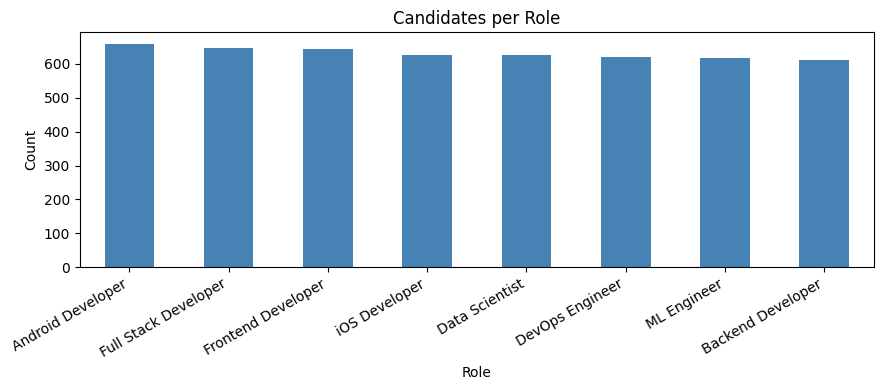

In [6]:
# Role distribution
plt.figure(figsize=(9, 4))
df["role_applied_for"].value_counts().plot(kind="bar", color="steelblue")
plt.title("Candidates per Role")
plt.xlabel("Role")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


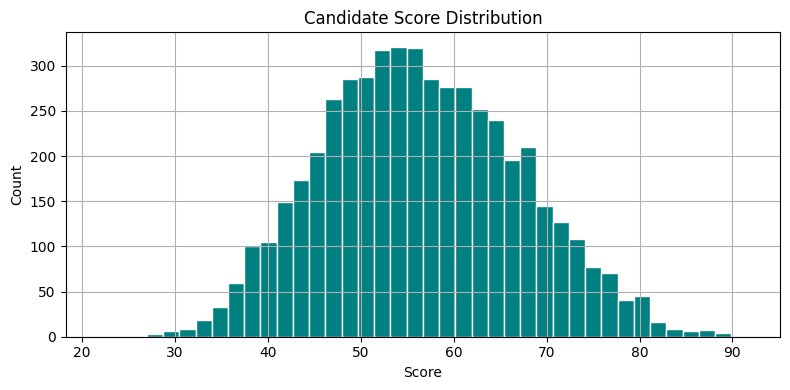

Score range: 21.7 to 91.6


In [7]:
# Score distribution
plt.figure(figsize=(8, 4))
df["candidate_score"].hist(bins=40, color="teal", edgecolor="white")
plt.title("Candidate Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()
print(f"Score range: {df.candidate_score.min():.1f} to {df.candidate_score.max():.1f}")


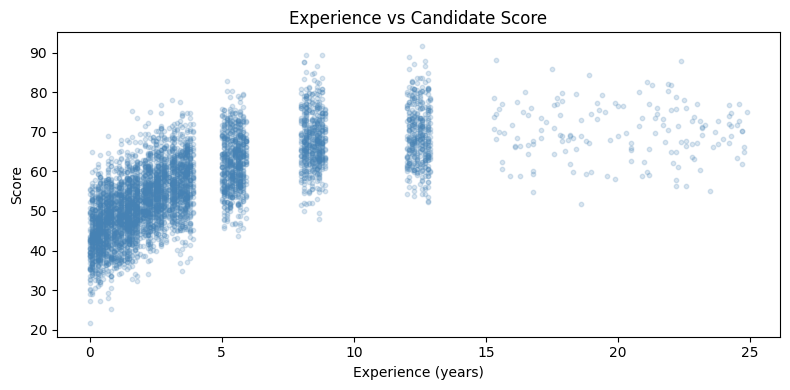

In [8]:
# Experience vs Score
plt.figure(figsize=(8, 4))
plt.scatter(df["total_experience_yrs"], df["candidate_score"], alpha=0.2, color="steelblue", s=10)
plt.title("Experience vs Candidate Score")
plt.xlabel("Experience (years)")
plt.ylabel("Score")
plt.tight_layout()
plt.show()


total_experience_yrs
(0, 2]        ₹700,000
(2, 5]      ₹1,130,000
(5, 10]     ₹1,740,000
(10, 25]    ₹2,440,000
Name: expected_salary_inr, dtype: str
                      skill_python  skill_react  skill_docker
role_applied_for                                             
Android Developer             0.09         0.12          0.11
Backend Developer             0.90         0.11          0.72
Data Scientist                0.97         0.11          0.48
DevOps Engineer               0.71         0.14          0.95
Frontend Developer            0.12         0.81          0.36
Full Stack Developer          0.63         0.76          0.60
ML Engineer                   0.96         0.12          0.78
iOS Developer                 0.13         0.11          0.11


<Axes: >

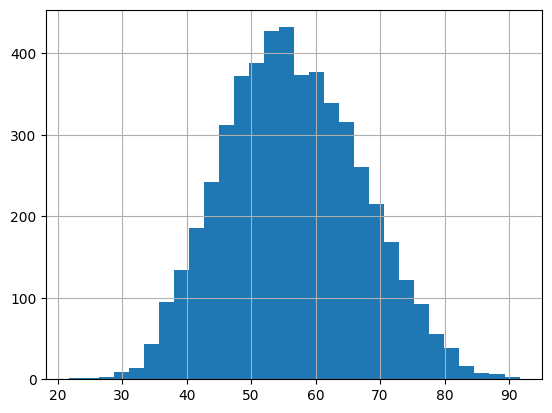

In [9]:
# Reality check 1 — salary should rise with experience
print(df.groupby(pd.cut(df.total_experience_yrs, bins=[0,2,5,10,25]))
        ["expected_salary_inr"].median().apply(lambda x: f"₹{int(x):,}"))

# Reality check 2 — skills should match roles
print(df.groupby("role_applied_for")[["skill_python","skill_react","skill_docker"]].mean().round(2))

# Reality check 3 — score should look like a bell curve
df["candidate_score"].hist(bins=30)

## 4. Clean Data

In [10]:
df_clean = df.copy()

# Step 1: Remove duplicates
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Removed duplicates : {before - len(df_clean)} rows")

# Step 2: Fix bad salary values (0, negative, impossibly high)
bad_salary_mask = (
    df_clean["expected_salary_inr"] <= 0) | (
    df_clean["expected_salary_inr"] > 10_000_000
)
print(f"Bad salary values  : {bad_salary_mask.sum()}")
df_clean.loc[bad_salary_mask, "expected_salary_inr"] = np.nan

# Step 3: Fill missing numeric columns with median
fill_cols = [
    "highest_cgpa", "num_certifications", "num_projects",
    "num_companies", "institute_tier", "expected_salary_inr",
    "highest_degree_rank"
]
for col in fill_cols:
    median = df_clean[col].median()
    missing_count = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna(median)
    print(f"Filled {missing_count:3d} missing in {col:30s} with median={median:.2f}")

# Step 4: Encode role
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_clean["role_encoded"] = le.fit_transform(df_clean["role_applied_for"])

print(f"\nClean dataset shape: {df_clean.shape}")
print(f"Missing values left: {df_clean.isnull().sum().sum()}")


Removed duplicates : 50 rows
Bad salary values  : 15
Filled 425 missing in highest_cgpa                   with median=7.01
Filled 479 missing in num_certifications             with median=0.00
Filled 350 missing in num_projects                   with median=3.00
Filled 245 missing in num_companies                  with median=1.00
Filled 268 missing in institute_tier                 with median=2.00
Filled 219 missing in expected_salary_inr            with median=1130000.00
Filled 151 missing in highest_degree_rank            with median=5.00

Clean dataset shape: (5000, 81)
Missing values left: 0


## 5. Feature Engineering

In [11]:
# Columns to scale
SCALE_COLS = [
    "total_experience_yrs", "expected_salary_inr", "highest_cgpa",
    "total_skills_count", "num_projects", "num_certifications", "num_companies",
]

# All feature columns (everything except target and non-numeric)
DROP_COLS = ["role_applied_for", "candidate_score"]
feature_cols = [c for c in df_clean.columns if c not in DROP_COLS]

X = df_clean[feature_cols].copy()
y = df_clean["candidate_score"].copy()

# Scale continuous columns
scaler = StandardScaler()
X[SCALE_COLS] = scaler.fit_transform(X[SCALE_COLS])

print(f"Features : {len(feature_cols)}")
print(f"Target   : candidate_score")
print(f"X shape  : {X.shape}")
print(f"y range  : {y.min():.1f} - {y.max():.1f}")


Features : 79
Target   : candidate_score
X shape  : (5000, 79)
y range  : 21.7 - 91.6


## 6. Train / Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set : {X_train.shape[0]} rows")
print(f"Test set     : {X_test.shape[0]} rows")


Training set : 4000 rows
Test set     : 1000 rows


## 7. Train Random Forest Model

In [13]:
model = RandomForestRegressor(
    n_estimators=100,   # 100 trees
    max_depth=12,       # prevent overfitting
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1,          # use all CPU cores
)

print("Training model...")
model.fit(X_train, y_train)
print("Training done!")


Training model...
Training done!


## 8. Evaluate Model

In [14]:
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test  = mean_absolute_error(y_test,  y_pred_test)
r2_train  = r2_score(y_train, y_pred_train)
r2_test   = r2_score(y_test,  y_pred_test)

print("Model Evaluation")
print("-" * 35)
print(f"  Train MAE : {mae_train:.2f}  |  R² : {r2_train:.4f}")
print(f"  Test  MAE : {mae_test:.2f}  |  R² : {r2_test:.4f}")
print()
if r2_test > 0.85:
    print("Excellent fit!")
elif r2_test > 0.70:
    print("Good fit.")
else:
    print("Model needs improvement — try more iterations or features.")


Model Evaluation
-----------------------------------
  Train MAE : 1.77  |  R² : 0.9521
  Test  MAE : 3.02  |  R² : 0.8712

Excellent fit!


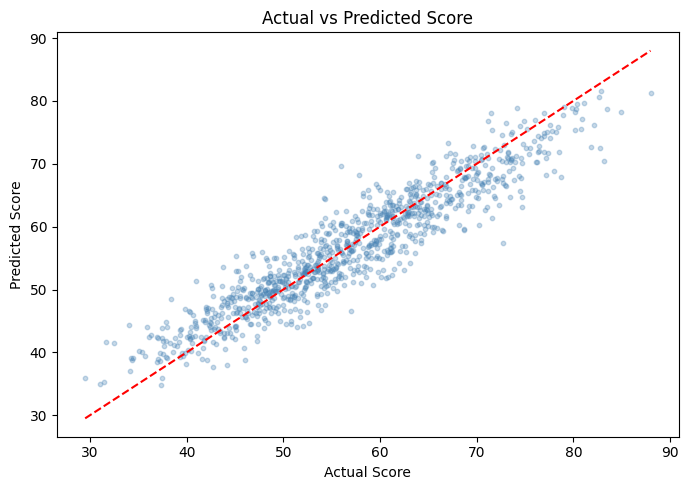

In [15]:
# Actual vs Predicted plot
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_test, alpha=0.3, s=10, color="steelblue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=1.5)
plt.title("Actual vs Predicted Score")
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.tight_layout()
plt.show()


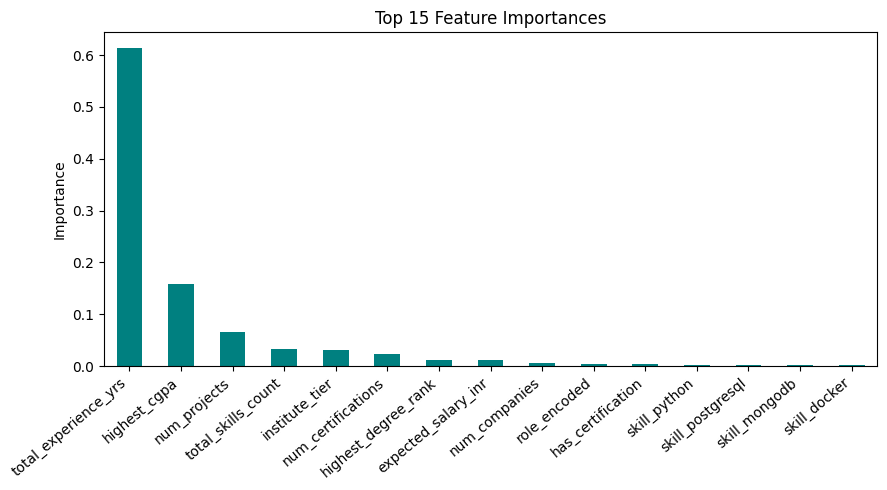

In [16]:
# Top 15 important features
importances = pd.Series(model.feature_importances_, index=feature_cols)
top15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 5))
top15.plot(kind="bar", color="teal")
plt.title("Top 15 Feature Importances")
plt.ylabel("Importance")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()


## 9. Save Model, Scaler, Feature Columns

In [17]:
# Save model
joblib.dump(model, RANKING_MODEL_PATH)
print(f"Saved model         : {RANKING_MODEL_PATH}")

# Save scaler
joblib.dump(scaler, SCALER_PATH)
print(f"Saved scaler        : {SCALER_PATH}")

# Save feature column names (important — app must use same columns in same order)
joblib.dump(feature_cols, FEATURE_COLS_PATH)
print(f"Saved feature cols  : {FEATURE_COLS_PATH}")
print(f"Total features saved: {len(feature_cols)}")

print("\nStep 4 complete! All model files saved.")
print("Next: run the Flask app with  python app.py")


Saved model         : c:\Users\GARG\RESUMES PBL\models\ranking_model.pkl
Saved scaler        : c:\Users\GARG\RESUMES PBL\models\scaler.pkl
Saved feature cols  : c:\Users\GARG\RESUMES PBL\models\feature_columns.pkl
Total features saved: 79

Step 4 complete! All model files saved.
Next: run the Flask app with  python app.py
